# Phân cụm khách hàng — Huấn luyện mô hình (K-Means, Hierarchical, DBSCAN)

Notebook này thực hiện:
1. Tìm số cụm k tối ưu bằng phương pháp Elbow + Silhouette
2. Huấn luyện và đánh giá 3 mô hình: **K-Means**, **Hierarchical (Agglomerative)**, **DBSCAN**
3. So sánh 3 mô hình
4. Phân tích đặc điểm (business profiling) của các cụm theo mô hình tốt nhất

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import wandb

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

wandb.login()

# Đọc dữ liệu đã chuẩn hóa (dùng để huấn luyện)
processed_data_path = "../data/processed/customer_segmentation_scaled.csv"
X_df = pd.read_csv(processed_data_path)
X = X_df[['Recency', 'Frequency', 'Monetary']].values
print(f"Kích thước ma trận dữ liệu: {X.shape}")

# Đọc dữ liệu RFM thô (đơn vị gốc, dùng để diễn giải cụm sau này)
rfm_raw = pd.read_csv("../data/processed/customer_segmentation.csv")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Mrs Linh\_netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Kích thước ma trận dữ liệu: (4338, 3)


## 1. Tìm số cụm k tối ưu — phương pháp Elbow + Silhouette

In [2]:
run_tuning = wandb.init(
    project="customer-segmentation-online-retail",
    name="kmeans-k-tuning",
    job_type="hyperparameter-tuning",
    config={"k_min": 2, "k_max": 10}
)

k_range = range(2, 11)
results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)

    results.append({"k": k, "inertia": inertia, "silhouette": sil, "davies_bouldin": db})
    wandb.log({
        "num_clusters_k": k,
        "inertia": inertia,
        "silhouette_score": sil,
        "davies_bouldin_index": db
    })

wandb.finish()

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

wandb: Currently logged in as: uyentran12348 (uyentranngocphuong) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


davies_bouldin_index,▁█▆▇▅▅▇▆▇
inertia,█▆▄▃▂▂▂▁▁
num_clusters_k,▁▂▃▄▅▅▆▇█
silhouette_score,█▃▄▂▃▁▁▁▁
davies_bouldin_index,1.04677
inertia,1879.47301
num_clusters_k,10
silhouette_score,0.2844


 k     inertia  silhouette  davies_bouldin
 2 6094.054981    0.444776        0.864287
 3 4607.448950    0.338251        1.076196
 4 3698.765267    0.343782        1.005117
 5 3129.088303    0.311585        1.048360
 6 2695.165136    0.316885        0.974813
 7 2418.216052    0.288543        0.985662
 8 2216.440957    0.279194        1.042126
 9 2029.820895    0.288125        1.024454
10 1879.473010    0.284396        1.046772


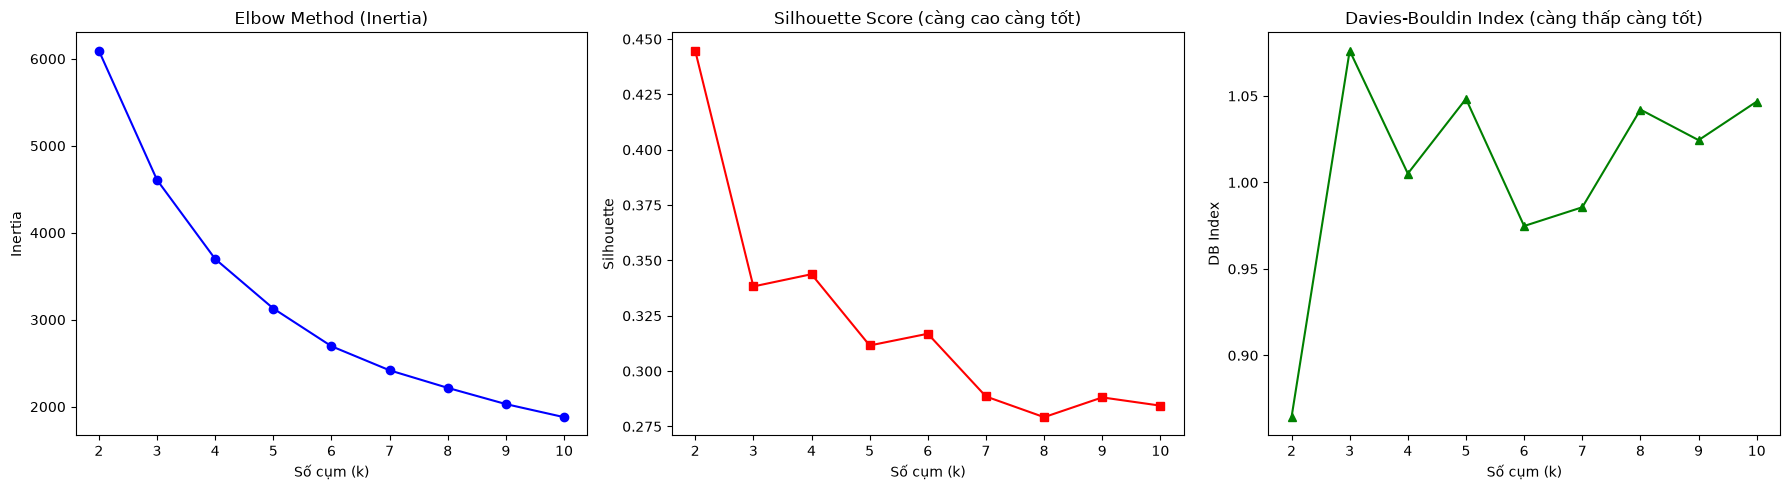

In [3]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_df['k'], results_df['inertia'], marker='o', color='b')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Số cụm (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(results_df['k'], results_df['silhouette'], marker='s', color='r')
axes[1].set_title('Silhouette Score (càng cao càng tốt)')
axes[1].set_xlabel('Số cụm (k)')
axes[1].set_ylabel('Silhouette')

axes[2].plot(results_df['k'], results_df['davies_bouldin'], marker='^', color='g')
axes[2].set_title('Davies-Bouldin Index (càng thấp càng tốt)')
axes[2].set_xlabel('Số cụm (k)')
axes[2].set_ylabel('DB Index')

plt.tight_layout()
plt.show()

## 2. Chọn k tối ưu

Tuy K=2 cao nhất nhưng phân cụm thành 2 là quá ít và không mang lại nhiều giá trị. Nên chọn K=4 (cái cao nhì)

In [5]:
optimal_k = 4



## 3. Huấn luyện 3 mô hình phân cụm

### 3.1 K-Means

In [6]:
with wandb.init(project="customer-segmentation-online-retail", name=f"model-kmeans-k{optimal_k}_new", job_type="train") as run:
    kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    kmeans_labels = kmeans_model.fit_predict(X)

    kmeans_sil = silhouette_score(X, kmeans_labels)
    kmeans_db = davies_bouldin_score(X, kmeans_labels)
    wandb.log({"final_silhouette": kmeans_sil, "final_davies_bouldin": kmeans_db})
    print(f"K-Means | Silhouette: {kmeans_sil:.4f} | DB Index: {kmeans_db:.4f}")

    os.makedirs("models", exist_ok=True)
    joblib.dump(kmeans_model, f"models/kmeans_model_k{optimal_k}_new.pkl")
    artifact = wandb.Artifact(name=f"kmeans_model_k{optimal_k}_new", type="model")
    artifact.add_file(f"models/kmeans_model_k{optimal_k}_new.pkl")
    run.log_artifact(artifact)

K-Means | Silhouette: 0.3438 | DB Index: 1.0051


final_davies_bouldin,▁
final_silhouette,▁
final_davies_bouldin,1.00512
final_silhouette,0.34378


### 3.2 Hierarchical Clustering (Agglomerative)

In [7]:
with wandb.init(project="customer-segmentation-online-retail", name=f"model-hierarchical-wk{optimal_k}_new", job_type="train") as run:
    hier_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
    hier_labels = hier_model.fit_predict(X)

    hier_sil = silhouette_score(X, hier_labels)
    hier_db = davies_bouldin_score(X, hier_labels)
    wandb.log({"final_silhouette": hier_sil, "final_davies_bouldin": hier_db})
    print(f"Hierarchical | Silhouette: {hier_sil:.4f} | DB Index: {hier_db:.4f}")

    joblib.dump(hier_model, f"models/hierarchical_model_wk{optimal_k}_new.pkl")
    artifact = wandb.Artifact(name=f"hierarchical_model_wk{optimal_k}_new", type="model")
    artifact.add_file(f"models/hierarchical_model_wk{optimal_k}_new.pkl")
    run.log_artifact(artifact)

Hierarchical | Silhouette: 0.2883 | DB Index: 1.1143


final_davies_bouldin,▁
final_silhouette,▁
final_davies_bouldin,1.1143
final_silhouette,0.28831


### 3.3 DBSCAN

DBSCAN không dùng k — thay vào đó cần chọn `eps` (bán kính lân cận). Chọn `eps` bằng cách nhìn **k-distance graph** (điểm gãy khuỷu tay), tránh đoán mò (đoán mò dễ khiến DBSCAN gộp hết vào 1 cụm hoặc coi phần lớn dữ liệu là nhiễu).

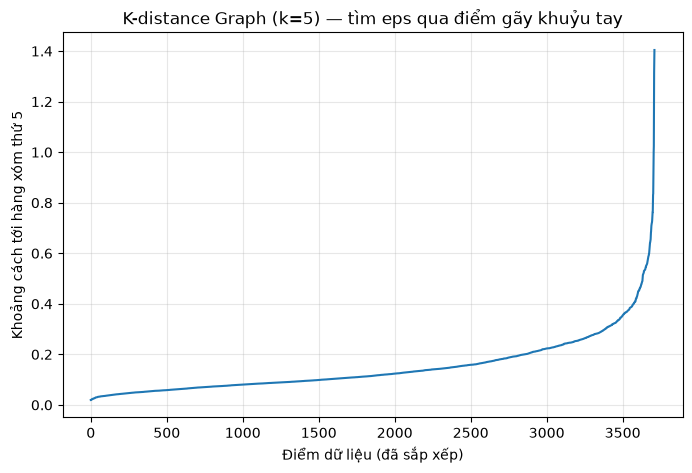

Dự đoán eps: 0.2837 (hãy đối chiếu với điểm gãy khuỷu tay trên đồ thị)


In [10]:
min_samples = 5  # nhiều hơn số chiều dữ liệu (RFM = 3 chiều -> tối thiểu 4, chọn 5 cho an toàn) vì DBSCAN yêu cầu min_samples >= số chiều dữ liệu + 1

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

k_distances = np.sort(distances[:, min_samples - 1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title(f'K-distance Graph (k={min_samples}) — tìm eps qua điểm gãy khuỷu tay')
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel(f'Khoảng cách tới hàng xóm thứ {min_samples}')
plt.grid(True, alpha=0.3)
plt.show()

# Dự đoán điểm gãy khuỷu tay = percentile 90 
eps_suggested = float(np.percentile(k_distances, 90))
print(f"Dự đoán eps: {eps_suggested:.4f} (hãy đối chiếu với điểm gãy khuỷu tay trên đồ thị)")

In [11]:
eps_range = np.arange(0.3, 1.5, 0.1) 
dbscan_results = []

for eps_test in eps_range:
    model = DBSCAN(eps=eps_test, min_samples=min_samples)
    labels = model.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters >= 2:
        mask = labels != -1
        sil = silhouette_score(X[mask], labels[mask])
    else:
        sil = None
    
    dbscan_results.append({"eps": eps_test, "n_clusters": n_clusters, "n_noise": n_noise, "silhouette": sil})

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df.to_string(index=False))

 eps  n_clusters  n_noise  silhouette
 0.3          15      207    0.077474
 0.4           8       72    0.105783
 0.5           5       40    0.165109
 0.6           2       12    0.319691
 0.7           2        9    0.319614
 0.8           2        4    0.319345
 0.9           1        3         NaN
 1.0           1        3         NaN
 1.1           1        0         NaN
 1.2           1        0         NaN
 1.3           1        0         NaN
 1.4           1        0         NaN


In [12]:
eps = 0.6

with wandb.init(project="customer-segmentation-online-retail", name=f"model-dbscan-weps{eps:.3f}", job_type="train") as run:
    dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan_model.fit_predict(X)

    num_clusters_found = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    num_noise = list(dbscan_labels).count(-1)
    print(f"DBSCAN tìm được {num_clusters_found} cụm, {num_noise:,} điểm nhiễu ({num_noise/len(X)*100:.1f}%)")

    if num_clusters_found >= 2:
        # Silhouette/DB Index chỉ tính được trên các điểm KHÔNG phải nhiễu (label != -1)
        mask = dbscan_labels != -1
        dbscan_sil = silhouette_score(X[mask], dbscan_labels[mask])
        dbscan_db = davies_bouldin_score(X[mask], dbscan_labels[mask])
        wandb.log({
            "final_silhouette": dbscan_sil,
            "final_davies_bouldin": dbscan_db,
            "num_clusters": num_clusters_found,
            "num_noise": num_noise
        })
        print(f"DBSCAN | Silhouette: {dbscan_sil:.4f} | DB Index: {dbscan_db:.4f}")
    else:
        dbscan_sil, dbscan_db = None, None
        print("DBSCAN không tìm đủ >= 2 cụm với eps hiện tại — hãy thử eps khác dựa trên k-distance graph phía trên.")

    joblib.dump(dbscan_model, f"models/dbscan_model_weps{eps:.3f}.pkl")
    artifact = wandb.Artifact(name=f"dbscan_model_weps{eps:.3f}", type="model")
    artifact.add_file(f"models/dbscan_model_weps{eps:.3f}.pkl")
    run.log_artifact(artifact)

DBSCAN tìm được 2 cụm, 12 điểm nhiễu (0.3%)
DBSCAN | Silhouette: 0.3197 | DB Index: 1.0706


wandb: WARNING Artifact "dbscan_model_weps0.600" already exists with the same content. No new version will be created.


final_davies_bouldin,▁
final_silhouette,▁
num_clusters,▁
num_noise,▁
final_davies_bouldin,1.07056
final_silhouette,0.31969
num_clusters,2
num_noise,12


## 4. So sánh 3 mô hình

In [ ]:
comparison = pd.DataFrame([
    {"Model": "K-Means", "So cum": optimal_k, "Silhouette": kmeans_sil, "Davies-Bouldin": kmeans_db},
    {"Model": "Hierarchical", "So cum": optimal_k, "Silhouette": hier_sil, "Davies-Bouldin": hier_db},
    {"Model": "DBSCAN", "So cum": num_clusters_found, "Silhouette": dbscan_sil, "Davies-Bouldin": dbscan_db},
])
print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
comparison.plot(x='Model', y='Silhouette', kind='bar', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Silhouette Score (càng cao càng tốt)')
axes[0].set_ylabel('Silhouette')
comparison.plot(x='Model', y='Davies-Bouldin', kind='bar', ax=axes[1], legend=False, color='salmon')
axes[1].set_title('Davies-Bouldin Index (càng thấp càng tốt)')
axes[1].set_ylabel('DB Index')
plt.tight_layout()
plt.show()

## 5. Phân tích đặc điểm từng cụm (Business Profiling) — theo mô hình tốt nhất

In [ ]:
candidates = {"K-Means": (kmeans_labels, kmeans_sil), "Hierarchical": (hier_labels, hier_sil)}
if dbscan_sil is not None:
    candidates["DBSCAN"] = (dbscan_labels, dbscan_sil)

best_model_name = max(candidates, key=lambda m: candidates[m][1])
best_labels = candidates[best_model_name][0]
print(f"Mô hình tốt nhất theo Silhouette: {best_model_name} ({candidates[best_model_name][1]:.4f})")

rfm_raw = rfm_raw.copy()
rfm_raw['Cluster'] = best_labels

cluster_summary = rfm_raw.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_counts = rfm_raw.groupby('Cluster').size().rename('So luong khach')
cluster_summary = cluster_summary.join(cluster_counts)
print(cluster_summary)

metrics_only = cluster_summary[['Recency', 'Frequency', 'Monetary']]
cluster_summary_scaled = (metrics_only - metrics_only.min()) / (metrics_only.max() - metrics_only.min())

plt.figure(figsize=(7, 5))
sns.heatmap(cluster_summary_scaled, annot=metrics_only, fmt=".1f", cmap="YlGnBu")
plt.title(f'Business Heatmap — {best_model_name}')
plt.show()

## 6. Dự đoán cụm cho TOÀN BỘ khách hàng (bao gồm cả outlier) và xuất file kết quả cuối cùng

**Vì sao cần bước này:** outlier chỉ nên bị loại khi **huấn luyện** mô hình (để tâm cụm không bị kéo lệch), nhưng không được loại khỏi **kết quả đầu ra** — đó vẫn là khách hàng thật, doanh nghiệp cần biết họ thuộc nhóm nào.

**Vì sao dùng K-Means cho bước này:** trong 3 mô hình, chỉ K-Means hỗ trợ `.predict()` để gán cụm cho dữ liệu mới/ngoài mẫu (out-of-sample) mà không cần train lại — cần thiết để phục vụ REST API sau này. Hierarchical và DBSCAN không hỗ trợ dự đoán theo cách này.

In [16]:
# Đọc lại toàn bộ RFM gốc 
rfm_full = pd.read_csv("../data/processed/customer_segmentation_full.csv")
scaler = joblib.load("models/rfm_scaler.pkl")


In [17]:
# Áp dụng ĐÚNG pipeline biến đổi đã dùng lúc train: log1p -> transform bằng scaler đã fit (KHÔNG fit lại)
rfm_full_log = rfm_full[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)
X_full_scaled = scaler.transform(rfm_full_log)

# Dự đoán cụm cho TẤT CẢ khách hàng bằng K-Means đã huấn luyện
rfm_full['Cluster'] = kmeans_model.predict(X_full_scaled)


print(f"Đã dự đoán cụm cho toàn bộ {rfm_full.shape[0]:,} khách hàng.")
rfm_full.head()

Đã dự đoán cụm cho toàn bộ 4,338 khách hàng.


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,325,1,77183.60,2
1,12347,1,7,4310.00,3
2,12348,74,4,1797.24,2
3,12349,18,1,1757.55,0
4,12350,309,1,334.40,1


### 6.1 Gán tên persona (nhãn kinh doanh) cho từng cụm

In [18]:
import os
import json as _json
from datetime import datetime, timedelta
from groq import Groq
from dotenv import load_dotenv

# Tự động nạp các biến môi trường từ file .env vào os.environ
load_dotenv()

# 1. Tính đặc điểm trung bình từng cụm (giữ làm ngữ cảnh cho LLM + fallback an toàn)
cluster_stats = rfm_full[rfm_full['Cluster'] != -1].groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_stats['SoLuongKhach'] = rfm_full[rfm_full['Cluster'] != -1].groupby('Cluster').size()
cluster_stats['rank_recency'] = cluster_stats['Recency'].rank(ascending=True)
cluster_stats['rank_frequency'] = cluster_stats['Frequency'].rank(ascending=False)
cluster_stats['rank_monetary'] = cluster_stats['Monetary'].rank(ascending=False)
cluster_stats['rank_score'] = cluster_stats[['rank_recency', 'rank_frequency', 'rank_monetary']].mean(axis=1)
cluster_stats = cluster_stats.sort_values('rank_score')

print("=== Đặc trưng các cụm hiện tại ===")
print(cluster_stats[['Recency', 'Frequency', 'Monetary', 'SoLuongKhach']])

# Bộ nhãn dự phòng (fallback) nếu gọi API lỗi
fallback_persona_pool = [
    "Khách hàng VIP (Champions)",
    "Khách hàng trung thành",
    "Khách hàng tiềm năng",
    "Khách hàng cần chăm sóc",
    "Khách hàng có nguy cơ rời bỏ",
    "Khách hàng không hoạt động"
]

# 2. Xây prompt mô tả đặc điểm từng cụm, yêu cầu LLM đặt tên persona bằng tiếng Việt
cluster_description = "\n".join([
    f"- Cluster {cid}: Recency trung bình = {row['Recency']:.1f} ngày, "
    f"Frequency trung bình = {row['Frequency']:.1f} đơn hàng, "
    f"Monetary trung bình = {row['Monetary']:,.0f}, "
    f"số lượng khách hàng = {int(row['SoLuongKhach'])}"
    for cid, row in cluster_stats.iterrows()
])

prompt = f"""Bạn là chuyên gia phân tích khách hàng (CRM/Marketing). Dưới đây là kết quả phân cụm khách hàng theo mô hình RFM (Recency = số ngày từ lần mua gần nhất, càng THẤP càng tốt; Frequency = số đơn hàng, càng CAO càng tốt; Monetary = tổng chi tiêu, càng CAO càng tốt):

{cluster_description}

Với MỖI cluster ở trên, hãy đặt:
1. "persona": một tên phân khúc khách hàng ngắn gọn bằng tiếng Việt (3-6 từ, ví dụ: "Khách hàng VIP", "Khách hàng có nguy cơ rời bỏ")
2. "description": mô tả ngắn 1 câu về đặc điểm hành vi và gợi ý chiến lược chăm sóc/marketing phù hợp cho nhóm đó

Chỉ trả về JSON hợp lệ theo đúng định dạng sau, không thêm giải thích hay markdown:
{{"0": {{"persona": "...", "description": "..."}}, "1": {{"persona": "...", "description": "..."}}}}
"""

# 3. Gọi Groq API
cluster_to_persona = {}
cluster_to_description = {}

try:
    api_key = os.environ.get("GROQ_API_KEY")
    if not api_key:
        raise ValueError("Không tìm thấy GROQ_API_KEY trong môi trường hoặc file .env")
        
    client = Groq(api_key=api_key)
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        response_format={"type": "json_object"}
    )
    raw_content = response.choices[0].message.content
    llm_result = _json.loads(raw_content)

    for cid in cluster_stats.index:
        key = str(cid)
        if key in llm_result and "persona" in llm_result[key]:
            cluster_to_persona[cid] = llm_result[key]["persona"]
            cluster_to_description[cid] = llm_result[key].get("description", "")
        else:
            raise KeyError(f"Thiếu kết quả cho cluster {cid}")

    print("\n[Thành công] Đã gọi Groq API để định danh persona.")

except Exception as e:
    print(f"\n[Thất bại] Gọi Groq API lỗi ({e}) -> Sử dụng bộ nhãn dự phòng (fallback theo rank_score).")
    cluster_to_persona = {
        cid: (fallback_persona_pool[i] if i < len(fallback_persona_pool) else f"Nhóm khách hàng {i+1}")
        for i, cid in enumerate(cluster_stats.index)
    }
    cluster_to_description = {cid: "Chưa có mô tả do lỗi kết nối AI." for cid in cluster_stats.index}

# 4. In bản đồ ánh xạ ra màn hình kiểm tra
print("\n=== Ánh xạ Cluster -> Persona ===")
for cid, name in cluster_to_persona.items():
    desc = cluster_to_description.get(cid, "")
    print(f"Cluster {cid} -> {name}" + (f" | {desc}" if desc else ""))

# 5. Khớp kết quả ngược lại dataframe tổng
rfm_full['Persona'] = rfm_full['Cluster'].map(cluster_to_persona)
rfm_full['Persona_Description'] = rfm_full['Cluster'].map(cluster_to_description)

# Xử lý các điểm nhiễu (mã là -1 nếu có từ DBSCAN/HDBSCAN)
rfm_full.loc[rfm_full['Cluster'] == -1, 'Persona'] = 'Không xác định (Nhiễu)'
rfm_full.loc[rfm_full['Cluster'] == -1, 'Persona_Description'] = 'Các bản ghi không thuộc bất kỳ nhóm hành vi đặc trưng nào.'

# Hiển thị kết quả mẫu
print("\n=== Dữ liệu phân cụm sau khi định danh (5 dòng đầu) ===")
print(rfm_full.head())

=== Đặc trưng các cụm hiện tại ===
            Recency  Frequency     Monetary  SoLuongKhach
Cluster                                                  
3         14.149793  11.630165  6503.082562           968
2         86.164003   3.436501  1527.925587          1189
0         18.683578   1.905207   473.850521           749
1        186.414106   1.229749   293.720259          1432

[Thành công] Đã gọi Groq API để định danh persona.

=== Ánh xạ Cluster -> Persona ===
Cluster 3 -> Khách hàng VIP | Là nhóm khách hàng có tần suất mua hàng cao, giá trị đơn hàng cao, cần được chăm sóc đặc biệt và ưu đãi để tăng cường lòng trung thành
Cluster 2 -> Khách hàng trung thành | Là nhóm khách hàng có tần suất mua hàng cao nhưng giá trị đơn hàng thấp, cần được chăm sóc và ưu đãi để tăng giá trị mua hàng
Cluster 0 -> Khách hàng mới | Là nhóm khách hàng mới, có tần suất mua thấp, cần được chăm sóc và khuyến mãi để tăng cường tương tác
Cluster 1 -> Khách hàng có nguy cơ rời bỏ | Là nhóm khách hàng có kho

### 6.2 Xuất file kết quả phân cụm cuối cùng

In [19]:
final_output_path = "../data/processed/customer_segments_final.csv"
rfm_full.to_csv(final_output_path, index=False, encoding="utf-8-sig")
print(f"Đã lưu file kết quả phân cụm cuối cùng tại: {final_output_path}")
print(f"Các cột: {list(rfm_full.columns)}")

print("\nSố lượng khách hàng theo Persona:")
print(rfm_full['Persona'].value_counts())

Đã lưu file kết quả phân cụm cuối cùng tại: ../data/processed/customer_segments_final.csv
Các cột: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Cluster', 'Persona', 'Persona_Description']

Số lượng khách hàng theo Persona:
Persona
Khách hàng có nguy cơ rời bỏ    1432
Khách hàng trung thành          1189
Khách hàng VIP                   968
Khách hàng mới                   749
Name: count, dtype: int64


## Kết luận

- 3 mô hình (K-Means, Hierarchical, DBSCAN) đều được huấn luyện và đánh giá bằng Silhouette Score + Davies-Bouldin Index.
- DBSCAN chọn `eps` dựa trên k-distance graph thay vì đoán mò.
- Mô hình có Silhouette cao nhất được dùng để phân tích đặc điểm từng cụm (business heatmap) phục vụ đặt chiến lược marketing/CSKH theo từng nhóm khách hàng.
`customer_segments_final.csv` — file này phục vụ báo cáo và REST API production.

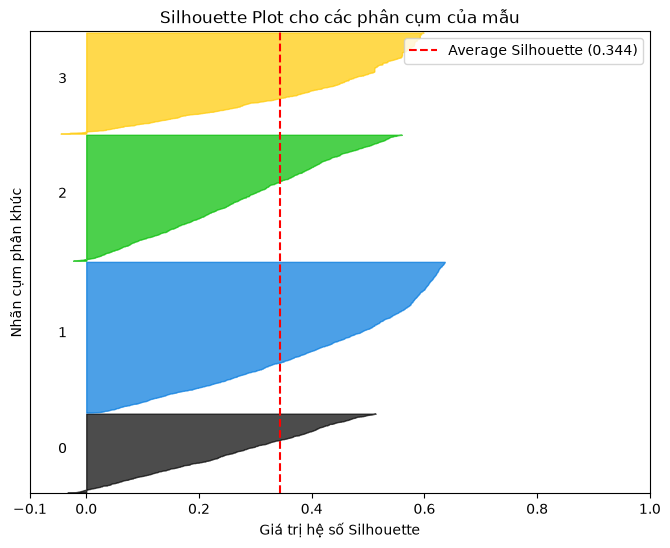

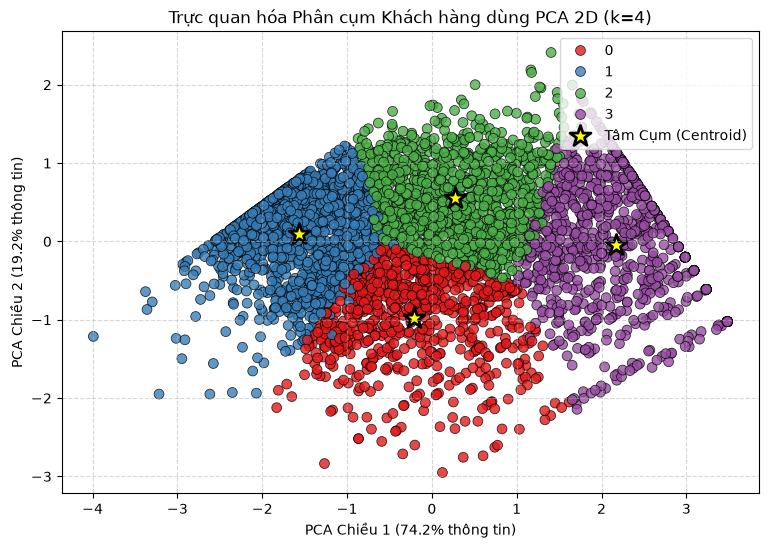

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.decomposition import PCA

# =========================================================================
# 1. VẼ BIỂU ĐỒ SILHOUETTE ANALYSIS (CHI TIẾT TỪNG CỤM)
# =========================================================================
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

# Giới hạn trục X từ -0.1 đến 1
ax1.set_xlim([-0.1, 1])
# Trục Y cần khoảng trống giữa các cụm
ax1.set_ylim([0, len(X) + (optimal_k + 1) * 10])

# Tính toán điểm silhouette cho từng mẫu dữ liệu
sample_silhouette_values = silhouette_samples(X, kmeans_labels)
cluster_labels = kmeans_labels
sil_score = silhouette_score(X, kmeans_labels)

y_lower = 10
for i in range(optimal_k):
    # Gom cụm các giá trị mẫu thuộc cụm i và sắp xếp chúng
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / optimal_k)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Dán nhãn số thứ tự cụm vào giữa các thanh đồ thị
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Tính toán vị trí đáy cho cụm tiếp theo
    y_lower = y_upper + 10  # 10 cho khoảng trống giữa các cụm

ax1.set_title("Silhouette Plot cho các phân cụm của mẫu")
ax1.set_xlabel("Giá trị hệ số Silhouette")
ax1.set_ylabel("Nhãn cụm phân khúc")

# Đường kẻ đứt nét biểu diễn giá trị Silhouette trung bình tổng thể
ax1.axvline(x=sil_score, color="red", linestyle="--", label=f"Average Silhouette ({sil_score:.3f})")
ax1.set_yticks([])  # Xóa các vạch số của trục Y
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax1.legend(loc="upper right")

plt.savefig(f"silhouette_analysis_k{optimal_k}.png")
plt.show()


# =========================================================================
# 2. TRỰC QUAN HÓA CỤM TRÊN KHÔNG GIAN HAI CHIỀU DÙNG PCA
# =========================================================================
# Vì dữ liệu RFM có 3 chiều (Recency, Frequency, Monetary), ta dùng PCA đưa về 2 chiều để vẽ đồ thị phẳng
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Tạo dataframe để vẽ seaborn dễ dàng
pca_df = pd.DataFrame(data=X_pca, columns=['PCA Chiều 1', 'PCA Chiều 2'])
pca_df['Cluster'] = kmeans_labels

plt.figure(figsize=(9, 6))
# Trực quan hóa sự phân tách giữa các cụm khách hàng
sns.scatterplot(
    x='PCA Chiều 1', y='PCA Chiều 2',
    hue='Cluster',
    palette=sns.color_palette('Set1', n_colors=optimal_k),
    data=pca_df,
    legend="full",
    alpha=0.8,
    edgecolor='k',
    s=50
)

# Lấy tọa độ các tâm cụm (centroids) và chiếu lên không gian PCA
centers_pca = pca.transform(kmeans_model.cluster_centers_)
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c='yellow', 
    s=250, 
    marker='*', 
    edgecolors='black', 
    linewidths=2,
    label='Tâm Cụm (Centroid)'
)

plt.title(f'Trực quan hóa Phân cụm Khách hàng dùng PCA 2D (k={optimal_k})')
plt.xlabel(f'PCA Chiều 1 ({pca.explained_variance_ratio_[0]*100:.1f}% thông tin)')
plt.ylabel(f'PCA Chiều 2 ({pca.explained_variance_ratio_[1]*100:.1f}% thông tin)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(f"kmeans_pca_scatter_k{optimal_k}.png")
plt.show()